In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv(r"C:\Users\cocle\OneDrive\Desktop\Project_2\UCI_Credit_Card.csv.zip", encoding="latin-1")

# understanding data - 
print(df.sample(10))
print(df.shape)
print(df.info()) 
print(df.describe())

          ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
22559  22560   300000.0    2          3         1   30      0      0      0   
7          8   100000.0    2          2         2   23      0     -1     -1   
11421  11422   140000.0    1          3         1   35      0      0      0   
24746  24747   420000.0    1          4         2   36      1     -2     -1   
4812    4813    50000.0    2          3         1   27     -1      0      0   
1803    1804    20000.0    2          1         2   31     -2     -2     -2   
10202  10203    90000.0    1          3         1   62      0      0     -1   
14948  14949   500000.0    1          2         2   30      1      0      0   
26702  26703    40000.0    1          1         2   29      1      2      2   
6244    6245   280000.0    1          1         2   28      0      0      0   

       PAY_4  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  \
22559      0  ...    27249.0    46007.0    46764.0    15

In [2]:
# finding missing values 

print(df.isna().sum()) 

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


<h2> EDA --> UNIVARIATE ANALYSIS</h2>

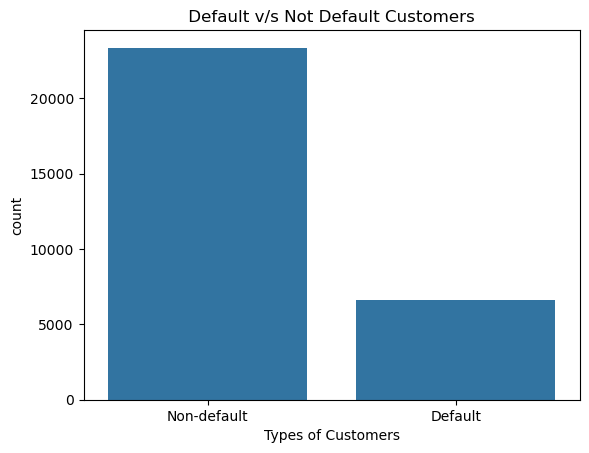

In [3]:
sns.countplot(data=df, x="default.payment.next.month")
plt.title(" Default v/s Not Default Customers ")
plt.xticks(ticks=[0,1], labels=["Non-default", "Default"])
plt.xlabel("Types of Customers")
plt.show()

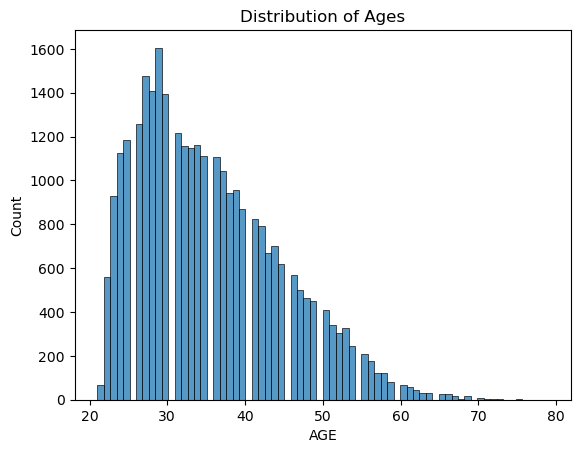

In [4]:
sns.histplot(data=df, x="AGE")
plt.title("Distribution of Ages")
plt.show()

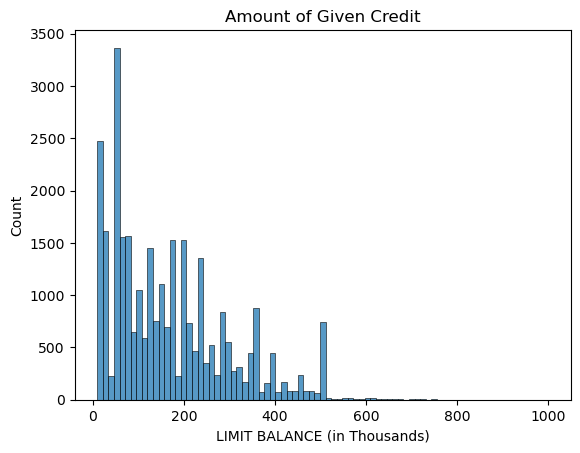

In [5]:
sns.histplot(data=df, x=(df["LIMIT_BAL"]/1000))
plt.title("Amount of Given Credit")
plt.xlabel("LIMIT BALANCE (in Thousands)")
plt.show()

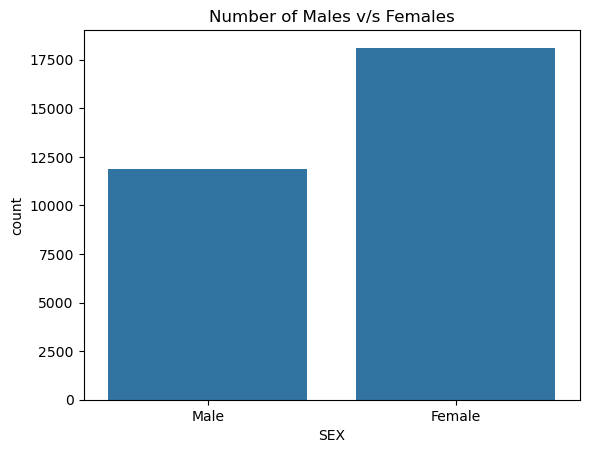

In [6]:
sns.countplot(data=df, x="SEX")  
plt.title("Number of Males v/s Females") 
plt.xticks(ticks=[0,1], labels=["Male","Female"])
plt.show()


<h4> Univariate analysis of Education and Marriage Columns </h4>

In [7]:
df["MARRIAGE"].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [8]:
df["EDUCATION"].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [9]:
# from the kaggle website and checking the data now, i found some undocumented category in the data, below i am fixing them 
df["EDUCATION"] = df["EDUCATION"].replace(0,5) 
df["EDUCATION"] = df["EDUCATION"].replace(6,5) 

print(df["EDUCATION"].value_counts())

df["MARRIAGE"] = df["MARRIAGE"].replace(0,3) 

print(df["MARRIAGE"].value_counts())

EDUCATION
2    14030
1    10585
3     4917
5      345
4      123
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64


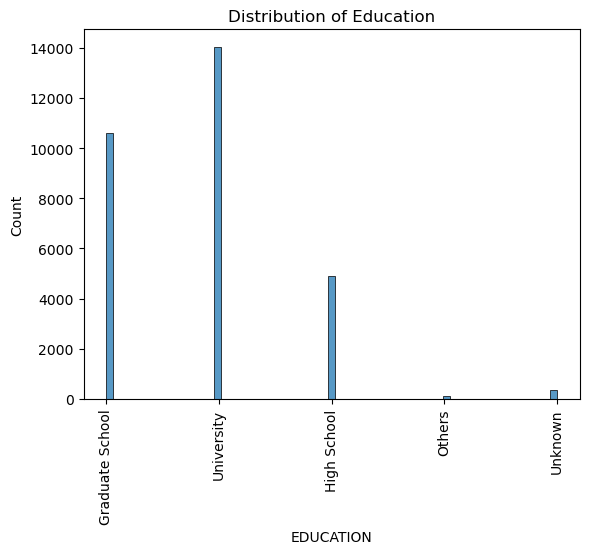

In [10]:
sns.histplot(data=df, x="EDUCATION")
plt.title("Distribution of Education")
plt.xticks(ticks=[1,2,3,4,5], labels=["Graduate School","University","High School","Others","Unknown"]) 
plt.xticks(rotation=90) 
plt.show()

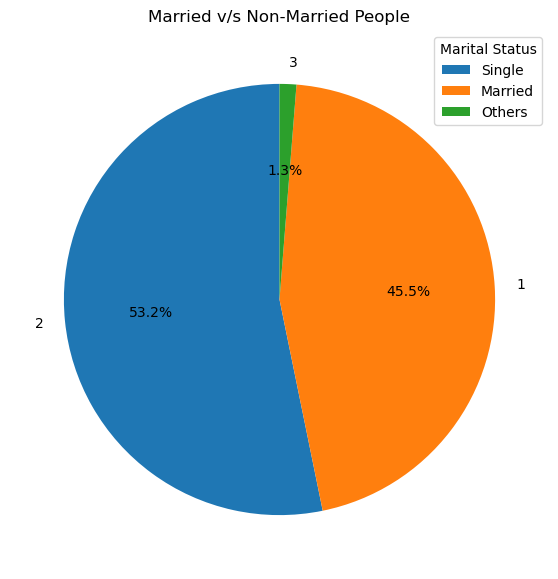

In [11]:
marriage_counts = df["MARRIAGE"].value_counts() 

label = {1:"Married",
         2:"Single",
         3:"Others"}
custom_label = [label.get(idx,"Unknown") for idx in marriage_counts.index]
plt.figure(figsize=(7,7))

plt.pie(marriage_counts, labels=marriage_counts.index, autopct="%1.1f%%", startangle=90) 

plt.legend(labels= custom_label, title="Marital Status", loc="upper right")
plt.title("Married v/s Non-Married People")
plt.show()

<h3> Univariate Analysis on Repayment behaviour </h3>

In [12]:
print(df["PAY_0"].unique())

for i in ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]:
    print("\n", i)
    print(df[i].value_counts().sort_index())

[ 2 -1  0 -2  1  3  4  8  7  5  6]

 PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

 PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

 PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

 PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

 PAY_5
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

 PAY_6
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7     

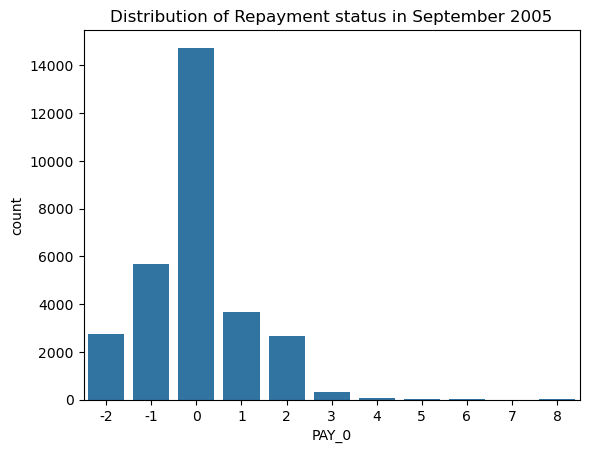

In [13]:
sns.countplot(data=df, x="PAY_0", order=sorted(df["PAY_0"].unique())) 
plt.title("Distribution of Repayment status in September 2005") 
plt.show()

<h2>BIVARIATE ANALYSIS</h2>

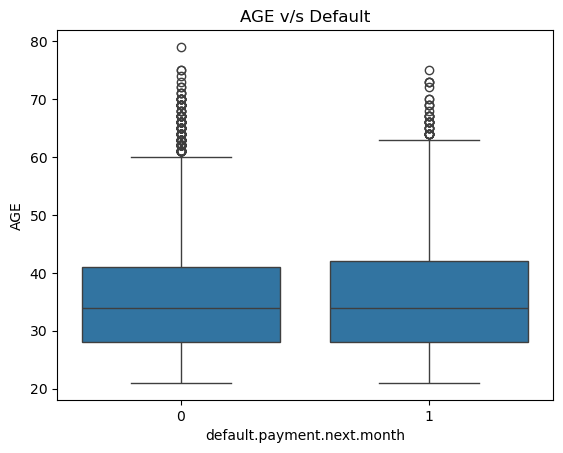

In [14]:
sns.boxplot(data=df, x="default.payment.next.month", y="AGE")
plt.title("AGE v/s Default")
plt.show()

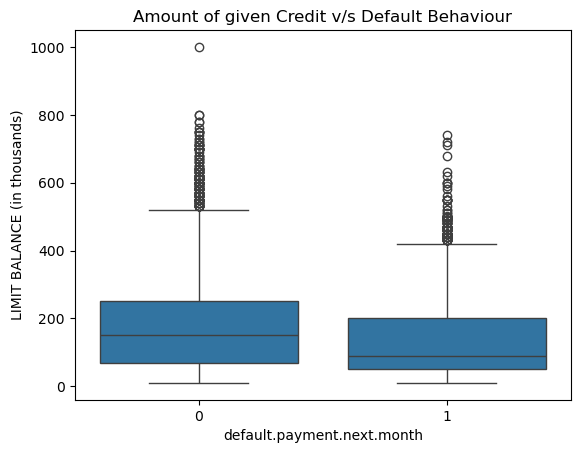

In [15]:
sns.boxplot(data=df, x="default.payment.next.month", y=(df["LIMIT_BAL"]/1000))
plt.ylabel("LIMIT BALANCE (in thousands)")
plt.title("Amount of given Credit v/s Default Behaviour")
plt.show()

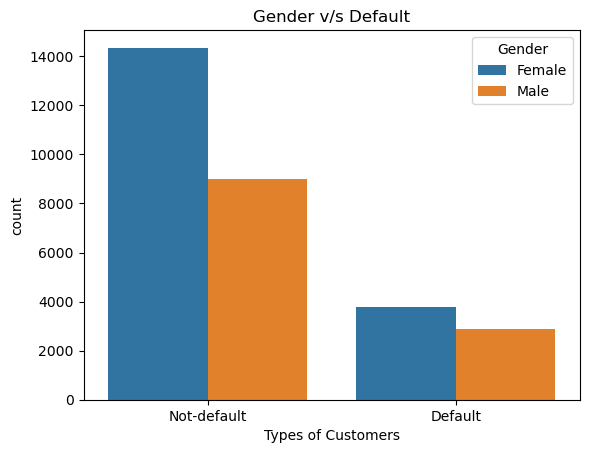

default.payment.next.month,0,1
Gender,,
Female,79.223719,20.776281
Male,75.832773,24.167227


In [16]:
gender_map = { 1:"Male",
               2:"Female"} 
df["Gender"] = df["SEX"].map(gender_map) 

sns.countplot(data=df, x="default.payment.next.month", hue="Gender")
plt.title("Gender v/s Default")
plt.xticks(ticks=[0,1],labels=["Not-default","Default"])
plt.xlabel("Types of Customers")
plt.show() 

pd.crosstab(df["Gender"],df["default.payment.next.month"],normalize="index")*100

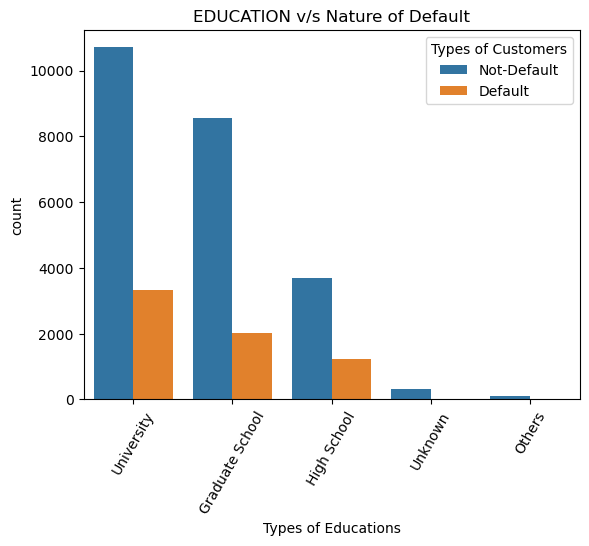

default.payment.next.month,0,1
education_LABEL,,
Graduate School,80.765234,19.234766
High School,74.842384,25.157616
Others,94.308943,5.691057
University,76.265146,23.734854
Unknown,92.463768,7.536232


In [17]:
education_map = {1:"Graduate School",
                 2:"University",
                 3:"High School",
                 4:"Others",
                 5:"Unknown"}
df["education_LABEL"] = df["EDUCATION"].map(education_map)

sns.countplot(data=df, x=df["education_LABEL"], hue="default.payment.next.month") 
plt.title("EDUCATION v/s Nature of Default") 
plt.legend(labels=["Not-Default", "Default"], title="Types of Customers", loc="upper right")
plt.xticks(rotation=60)
plt.xlabel("Types of Educations")
plt.show()

pd.crosstab(df["education_LABEL"],df["default.payment.next.month"],normalize="index")*100

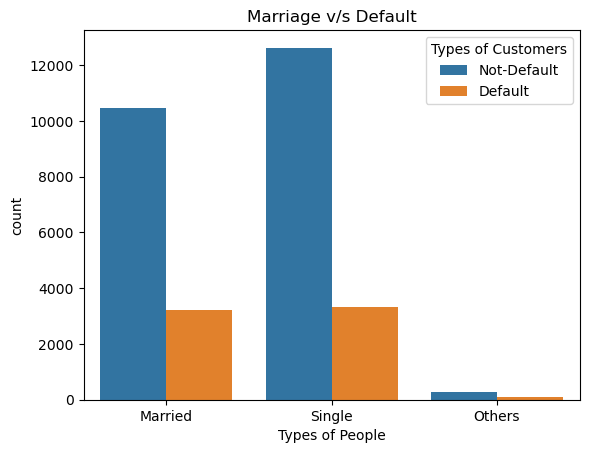

default.payment.next.month,0,1
marriage_LABEL,,
Married,76.528296,23.471704
Others,76.392573,23.607427
Single,79.071661,20.928339


In [18]:
df["marriage_LABEL"] = df["MARRIAGE"].map(label)

sns.countplot(data=df , x=df["marriage_LABEL"], hue="default.payment.next.month")
plt.title("Marriage v/s Default") 
plt.legend(labels=["Not-Default", "Default"], title="Types of Customers")
plt.xlabel("Types of People")
plt.show()

pd.crosstab(df["marriage_LABEL"],df["default.payment.next.month"],normalize="index")*100

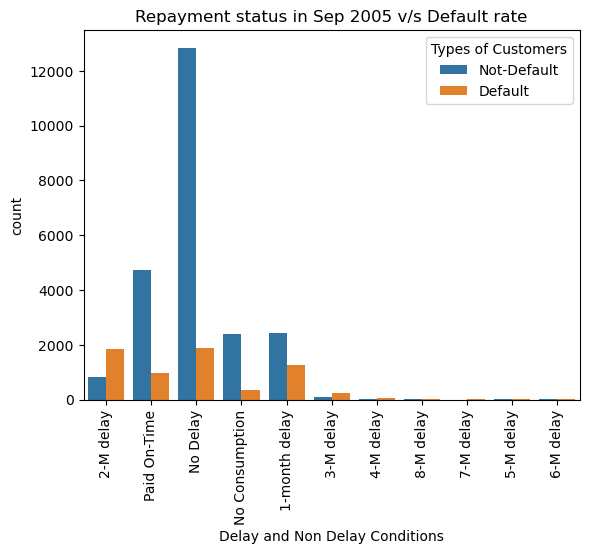

default.payment.next.month,0,1
pay0_LABEL,,
1-month delay,66.052061,33.947939
2-M delay,30.858643,69.141357
3-M delay,24.223602,75.776398
4-M delay,31.578947,68.421053
5-M delay,50.000000,50.000000
6-M delay,45.454545,54.545455
7-M delay,22.222222,77.777778
8-M delay,42.105263,57.894737
No Consumption,86.770569,13.229431


In [19]:
pay0_map={-2:"No Consumption",
          -1:"Paid On-Time",
          0:"No Delay",
          1:"1-month delay",
          2:"2-M delay",
          3:"3-M delay",
          4:"4-M delay",
          5:"5-M delay",
          6:"6-M delay",
          7:"7-M delay",
          8:"8-M delay",
          9:"9-M or more delay"}

df["pay0_LABEL"] = df["PAY_0"].map(pay0_map) 

sns.countplot(data= df, x=df["pay0_LABEL"], hue="default.payment.next.month")
plt.xticks(rotation=90) 
plt.title("Repayment status in Sep 2005 v/s Default rate") 
plt.legend(labels=["Not-Default", "Default"], title="Types of Customers")
plt.xlabel("Delay and Non Delay Conditions")
plt.show()

pd.crosstab(df["pay0_LABEL"], df["default.payment.next.month"], normalize="index")*100

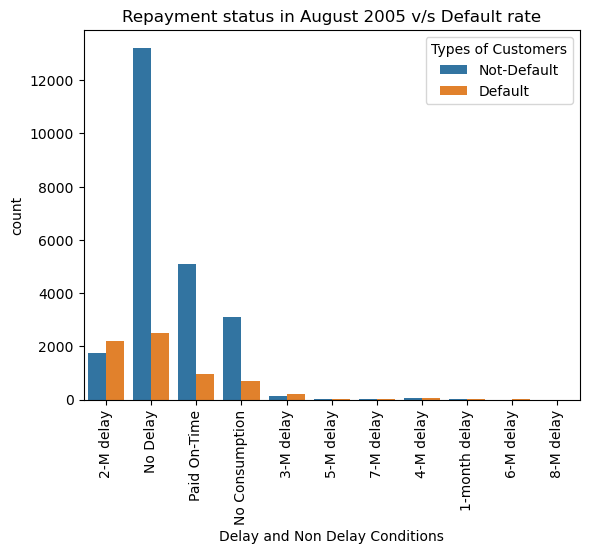

default.payment.next.month,0,1
pay2_LABEL,,
1-month delay,82.142857,17.857143
2-M delay,44.385027,55.614973
3-M delay,38.343558,61.656442
4-M delay,49.494949,50.505051
5-M delay,40.000000,60.000000
6-M delay,25.000000,75.000000
7-M delay,40.000000,60.000000
8-M delay,100.000000,0.000000
No Consumption,81.729244,18.270756


In [20]:
pay2_map={-2:"No Consumption",
          -1:"Paid On-Time",
          0:"No Delay",
          1:"1-month delay",
          2:"2-M delay",
          3:"3-M delay",
          4:"4-M delay",
          5:"5-M delay",
          6:"6-M delay",
          7:"7-M delay",
          8:"8-M delay",
          9:"9-M or more delay"}

df["pay2_LABEL"] = df["PAY_2"].map(pay2_map) 

sns.countplot(data= df, x=df["pay2_LABEL"], hue="default.payment.next.month")
plt.xticks(rotation=90) 
plt.title("Repayment status in August 2005 v/s Default rate") 
plt.legend(labels=["Not-Default", "Default"], title="Types of Customers")
plt.xlabel("Delay and Non Delay Conditions")
plt.show()

pd.crosstab(df["pay2_LABEL"], df["default.payment.next.month"], normalize="index")*100

In [21]:
for i in ["PAY_3","PAY_4","PAY_5","PAY_6"]: 
    print("\n",i) 
    print(pd.crosstab(df[i], df["default.payment.next.month"], normalize="index")*100)


 PAY_3
default.payment.next.month          0          1
PAY_3                                           
-2                          81.468788  18.531212
-1                          84.405524  15.594476
 0                          82.548845  17.451155
 1                          75.000000  25.000000
 2                          48.442001  51.557999
 3                          42.500000  57.500000
 4                          42.105263  57.894737
 5                          42.857143  57.142857
 6                          39.130435  60.869565
 7                          18.518519  81.481481
 8                          33.333333  66.666667

 PAY_4
default.payment.next.month          0          1
PAY_4                                           
-2                          80.749770  19.250230
-1                          84.104097  15.895903
 0                          81.671225  18.328775
 1                          50.000000  50.000000
 2                          47.673314  52.326686
 3  

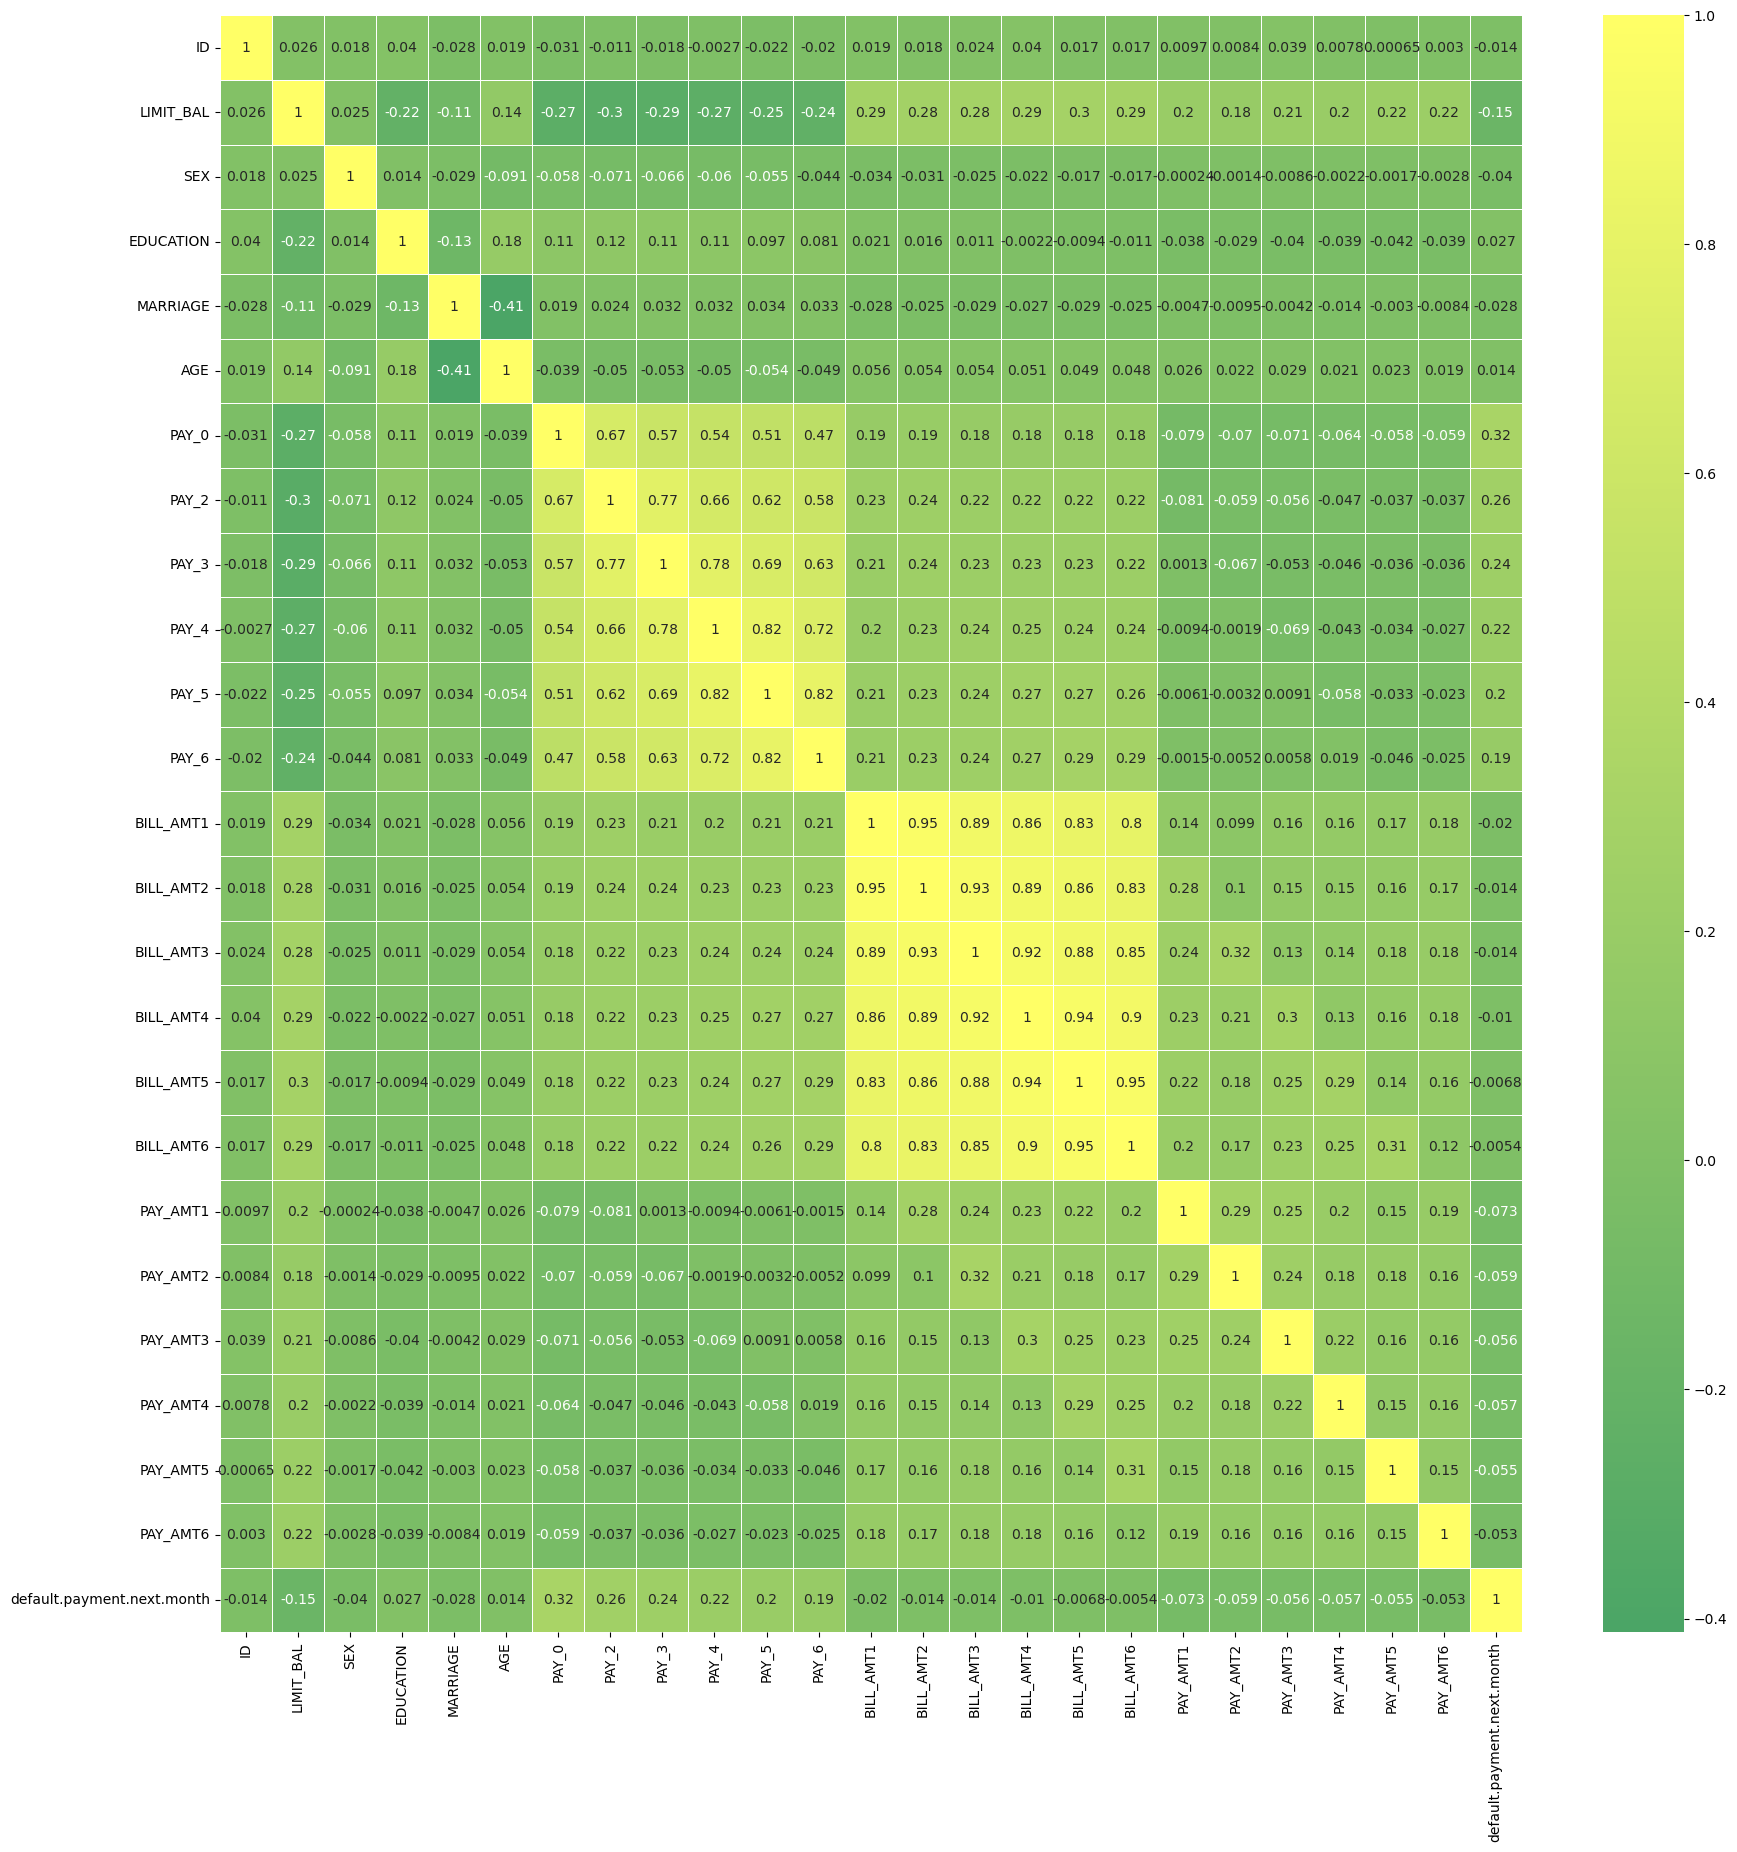

In [22]:
Correlation = df.corr(numeric_only=True) 
plt.figure(figsize=(21,21))
sns.heatmap(Correlation, cmap="summer", center=0, annot=True, linewidths=0.5) 
plt.show()

In [23]:
correlation_TARGET = df.corr(numeric_only=True)["default.payment.next.month"] 

print("Top positive Correlation for Next Month Default  ---->")
print(correlation_TARGET[correlation_TARGET>0].sort_values(ascending=False))
print("Top negative Correlation for Next Month Default  ----->")
print(correlation_TARGET[correlation_TARGET<0].sort_values())

Top positive Correlation for Next Month Default  ---->
default.payment.next.month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.026969
AGE                           0.013890
Name: default.payment.next.month, dtype: float64
Top negative Correlation for Next Month Default  ----->
LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
PAY_AMT3    -0.056250
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
SEX         -0.039961
MARRIAGE    -0.027575
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
ID          -0.013952
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
Name: default.payment.next.month, dtype: float64


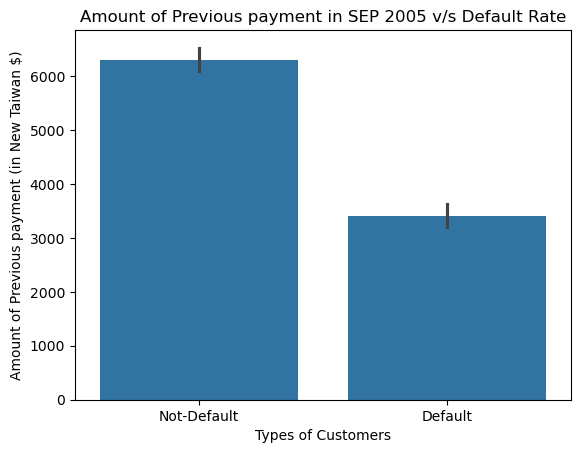

In [24]:
sns.barplot(data=df, x="default.payment.next.month", y="PAY_AMT1")
plt.title("Amount of Previous payment in SEP 2005 v/s Default Rate")
plt.xticks(ticks=[0,1],labels=["Not-Default","Default"])
plt.xlabel("Types of Customers")
plt.ylabel("Amount of Previous payment (in New Taiwan $)")
plt.show()

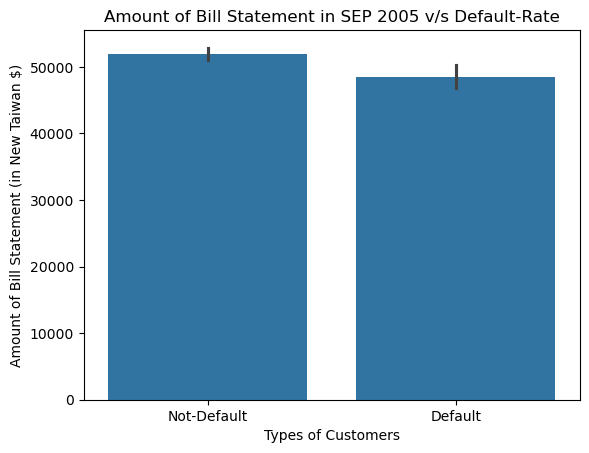

In [25]:
sns.barplot(data=df, x="default.payment.next.month", y="BILL_AMT1")
plt.title("Amount of Bill Statement in SEP 2005 v/s Default-Rate")
plt.xticks(ticks=[0,1],labels=["Not-Default","Default"])
plt.xlabel("Types of Customers")
plt.ylabel("Amount of Bill Statement (in New Taiwan $)")
plt.show()

In [26]:
print(df.groupby("default.payment.next.month")[["LIMIT_BAL","AGE","PAY_AMT1","PAY_AMT2","PAY_AMT3"]].median())

                            LIMIT_BAL   AGE  PAY_AMT1  PAY_AMT2  PAY_AMT3
default.payment.next.month                                               
0                            150000.0  34.0    2459.5    2247.5    2000.0
1                             90000.0  34.0    1636.0    1533.5    1222.0


<h3>FEATURE ENGINEERING</h3>

In [27]:
# Average Bill Amount -
df["Avg_Bill_Amt"]=df[["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]].mean(axis=1)

# Average Pay Amount -
df["Avg_Pay_Amt"]=df[["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]].mean(axis=1)

# PAYMENT RATIO - 
df["Pay_Ratio"]=( (df["Avg_Pay_Amt"])/(df["Avg_Bill_Amt"]+1) )

# Total Bill Amount - 
df["Total_Bill"]=df[["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]].sum(axis=1)

# Total Previous Paid Amount - 
df["Total_Payment"]=df[["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]].sum(axis=1)

# Credit Utilization Ratio - 
df["Credit_Utilized"]=( (df["Avg_Bill_Amt"])/(df["LIMIT_BAL"]+1) )

# Average Delay Rate of Customers - 
df["Avg_Delay"] = df[["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]].mean(axis=1)

# Checking Correlation for above features --> 
Correlation2 = df.corr(numeric_only=True)["default.payment.next.month"] 
print("Top Positive correlation ------> ") 
print(Correlation2[Correlation2>0].sort_values(ascending=False)) 
print("Top Negative correlation ------> ") 
print(Correlation2[Correlation2<0].sort_values())

Top Positive correlation ------> 
default.payment.next.month    1.000000
PAY_0                         0.324794
Avg_Delay                     0.281955
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
Credit_Utilized               0.115481
EDUCATION                     0.026969
AGE                           0.013890
Name: default.payment.next.month, dtype: float64
Top Negative correlation ------> 
LIMIT_BAL       -0.153520
Total_Payment   -0.102354
Avg_Pay_Amt     -0.102354
PAY_AMT1        -0.072929
PAY_AMT2        -0.058579
PAY_AMT4        -0.056827
PAY_AMT3        -0.056250
PAY_AMT5        -0.055124
PAY_AMT6        -0.053183
SEX             -0.039961
MARRIAGE        -0.027575
BILL_AMT1       -0.019644
BILL_AMT2       -0.014193
BILL_AMT3       -0.014076
ID              -0.013952
Avg_Bill_Amt    -0.012691
Total_Bill      -0.012691
BILL_AMT4   

In [28]:
df[["Avg_Delay","PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]].corr()
print(df["default.payment.next.month"].value_counts(normalize=True))

default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [29]:
df_new = df[["AGE","EDUCATION","SEX","MARRIAGE", "LIMIT_BAL","PAY_0","PAY_2","Avg_Delay","Total_Payment","Pay_Ratio","Credit_Utilized","default.payment.next.month"]] 
print(df_new)
print(df_new.isna().sum())

Correlation3 = df_new.corr(numeric_only=True)["default.payment.next.month"]
print("Top Positive correlation ------> ") 
print(Correlation3[Correlation3>0].sort_values(ascending=False)) 
print("Top Negative correlation ------> ") 
print(Correlation3[Correlation3<0].sort_values())

       AGE  EDUCATION  SEX  MARRIAGE  LIMIT_BAL  PAY_0  PAY_2  Avg_Delay  \
0       24          2    2         1    20000.0      2      2  -0.333333   
1       26          2    2         2   120000.0     -1      2   0.500000   
2       34          2    2         2    90000.0      0      0   0.000000   
3       37          2    2         1    50000.0      0      0   0.000000   
4       57          2    1         1    50000.0     -1      0  -0.333333   
...    ...        ...  ...       ...        ...    ...    ...        ...   
29995   39          3    1         1   220000.0      0      0   0.000000   
29996   43          3    1         2   150000.0     -1     -1  -0.666667   
29997   37          2    1         2    30000.0      4      3   1.333333   
29998   41          3    1         1    80000.0      1     -1  -0.166667   
29999   46          2    1         1    50000.0      0      0   0.000000   

       Total_Payment  Pay_Ratio  Credit_Utilized  default.payment.next.month  
0       

In [33]:
# got 2 missing values in the final datset (df_new), so removing them
df_new.dropna()
print(df_new.isna().sum())
print(df_new.shape)

AGE                           0
EDUCATION                     0
SEX                           0
MARRIAGE                      0
LIMIT_BAL                     0
PAY_0                         0
PAY_2                         0
Avg_Delay                     0
Total_Payment                 0
Pay_Ratio                     0
Credit_Utilized               0
default.payment.next.month    0
dtype: int64
(29998, 12)


<h3> MAKING THE ML MODEL </h3>

In [34]:
from sklearn.model_selection import train_test_split 

X = df_new.drop("default.payment.next.month",axis=1) 
y = df_new["default.payment.next.month"] 

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

# Standardising the input values 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

cols=["LIMIT_BAL","AGE","Avg_Delay","Total_Payment","Credit_Utilized","Pay_Ratio"]

X_train[cols] = scaler.fit_transform(X_train[cols])
X_test[cols] = scaler.transform(X_test[cols])

Accuracy : 0.6893333333333334
Precision : 0.37505816658911123
Recall : 0.6073850791258478
F-1 Score : 0.46375143843498273
ROC - AUC score : 0.7103508410079484


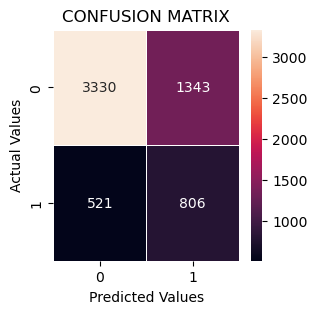

Classification Report : 
              precision    recall  f1-score   support

           0       0.86      0.71      0.78      4673
           1       0.38      0.61      0.46      1327

    accuracy                           0.69      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.69      0.71      6000



In [35]:
# Build LOGISTIC REGRESSION MODEL 
from sklearn.linear_model import LogisticRegression 
lr = LogisticRegression(random_state=42, class_weight="balanced")
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_probability = lr.predict_proba(X_test)[:,1]

# evalauate model 
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, roc_auc_score) 
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred)) 
print("Recall :", recall_score(y_test, y_pred))  
print("F-1 Score :", f1_score(y_test, y_pred))  
print("ROC - AUC score :", roc_auc_score(y_test,y_probability))

# Confusion matrix 
from sklearn.metrics import confusion_matrix 
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(3,3))
sns.heatmap(cm,annot=True,linewidths=0.5,fmt="d") 
plt.xlabel("Predicted Values") 
plt.ylabel("Actual Values")
plt.title("CONFUSION MATRIX")
plt.show()

# Classification Report 
from sklearn.metrics import classification_report 
print("Classification Report : ")
print(classification_report(y_test,y_pred))

Accuracy : 0.8208333333333333
Precision : 0.6962616822429907
Recall : 0.33685003767897514
F-1 Score : 0.4540375825292026
ROC - AUC score : 0.7517399010590268


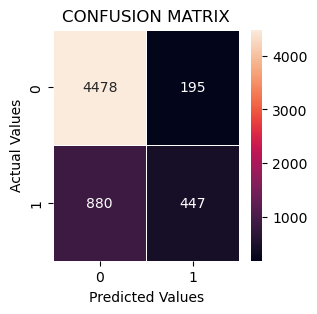

Classification Report : 
              precision    recall  f1-score   support

           0       0.84      0.96      0.89      4673
           1       0.70      0.34      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.77      0.65      0.67      6000
weighted avg       0.80      0.82      0.80      6000

Train Accuracy : 0.8235686307192266
Test Accuracy : 0.8208333333333333
Using Grid Search CV now ---->
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
0.7618845878973648
Accuracy : 0.7703333333333333
Precision : 0.48360128617363346
Recall : 0.5666917859834213
F-1 Score : 0.5218598195697433
ROC - AUC score : 0.7561280140156434
Train Accuracy : 0.7761063421951829
Test Accuracy : 0.7703333333333333


In [36]:
# Building Decision Tree Classifier 
from sklearn.tree import DecisionTreeClassifier 
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=20, min_samples_leaf=10, random_state=42) 
dt.fit(X_train, y_train) 

y_pred_dt = dt.predict(X_test)
y_probability_dt = dt.predict_proba(X_test)[:,1]

# evaulate model 
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, roc_auc_score) 
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision :", precision_score(y_test, y_pred_dt)) 
print("Recall :", recall_score(y_test, y_pred_dt))  
print("F-1 Score :", f1_score(y_test, y_pred_dt))  
print("ROC - AUC score :", roc_auc_score(y_test,y_probability_dt))

# Confusion matrix 
from sklearn.metrics import confusion_matrix 
cm = confusion_matrix(y_test,y_pred_dt)
plt.figure(figsize=(3,3))
sns.heatmap(cm,annot=True,linewidths=0.5,fmt="d") 
plt.xlabel("Predicted Values") 
plt.ylabel("Actual Values")
plt.title("CONFUSION MATRIX")
plt.show()

# Classification Report 
from sklearn.metrics import classification_report 
print("Classification Report : ")
print(classification_report(y_test,y_pred_dt))

# Check Overfitting (overfitting occured, we fixed with some paramters above)
train_score = dt.score(X_train, y_train) 
test_score = dt.score(X_test, y_test) 
print("Train Accuracy :", train_score) 
print("Test Accuracy :", test_score)

# Finding Optimal Parameters for Decision Tree using GridSearchCV 
print("Using Grid Search CV now ---->")
from sklearn.model_selection import GridSearchCV 
dt2 = DecisionTreeClassifier(random_state=42) 
param_grid = {
    "max_depth":[3,5,7,10,15],
    "min_samples_split":[2,5,10,20],
    "min_samples_leaf":[1,2,5,10],
    "criterion":["gini","entropy"],
    "class_weight":[None,"balanced"]} 
grid = GridSearchCV(estimator=dt2, param_grid=param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train,y_train) 

print(grid.best_params_) 
print(grid.best_score_)

# Train Best Model automatically
best_dt = grid.best_estimator_

y_pred = best_dt.predict(X_test)
y_probability_dt2 = best_dt.predict_proba(X_test)[:,1]

# evaulate again 
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, roc_auc_score) 
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred)) 
print("Recall :", recall_score(y_test, y_pred))  
print("F-1 Score :", f1_score(y_test, y_pred))  
print("ROC - AUC score :", roc_auc_score(y_test,y_probability_dt2))

train_score2 = best_dt.score(X_train, y_train) 
test_score2 = best_dt.score(X_test, y_test) 
print("Train Accuracy :", train_score2) 
print("Test Accuracy :", test_score2)

In [38]:
# Building Random Forest MODEL --> 
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced",n_jobs=-1) 
rf.fit(X_train,y_train) 

# y_pred_rf = rf.predict(X_test)
y_probability_rf =rf.predict_proba(X_test)[:,1] 

y_pred_35 = (y_probability_rf >= 0.35).astype(int)

# evaulate model 
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, roc_auc_score) 
print("Accuracy :", accuracy_score(y_test, y_pred_35))
print("Precision :", precision_score(y_test, y_pred_35)) 
print("Recall :", recall_score(y_test, y_pred_35))  
print("F-1 Score :", f1_score(y_test, y_pred_35))  
print("ROC - AUC score :", roc_auc_score(y_test,y_probability_rf))

# Training model using GridSearchCV 
print("Using Grid Search CV ---->")
rf2 = RandomForestClassifier(random_state=42, n_jobs=-1) 
param_grid2 = {"n_estimators":[100,200],
               "max_depth":[10,15], 
               "class_weight":["balanced"],
               }
grid_rf = GridSearchCV(estimator=rf2, param_grid=param_grid2, cv=3, scoring="roc_auc", n_jobs=-1, verbose=2)

grid_rf.fit(X_train,y_train) 

print("Best Parameters :") 
print(grid_rf.best_params_) 
print("\n Best ROC-AUC SCORE :")
print(grid_rf.best_score_)

# Train Best Model automatically 
best_rf = grid_rf.best_estimator_ 

# predict output values 
y_probability_rf2 = best_rf.predict_proba(X_test)[:,1]
y_pred_35_2 = (y_probability_rf2 >= 0.35).astype(int)

# evaulate model 
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)
print("Accuracy :", accuracy_score(y_test, y_pred_35_2))
print("Precision :", precision_score(y_test, y_pred_35_2)) 
print("Recall :", recall_score(y_test, y_pred_35_2))  
print("F-1 Score :", f1_score(y_test, y_pred_35_2))  
print("ROC - AUC score :", roc_auc_score(y_test,y_probability_rf2))
print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred_35_2))
print("\nClassification report :") 
print(classification_report(y_test, y_pred_35_2))

Accuracy : 0.7961666666666667
Precision : 0.5436241610738255
Recall : 0.4883195177091183
F-1 Score : 0.5144898769352918
ROC - AUC score : 0.7554455512604193
Using Grid Search CV ---->
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Parameters :
{'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 200}

 Best ROC-AUC SCORE :
0.7783275347376845
Accuracy : 0.6463333333333333
Precision : 0.3581876560827685
Recall : 0.7565938206480783
F-1 Score : 0.4861985472154964
ROC - AUC score : 0.774334627034588

Confusion Matrix :
[[2874 1799]
 [ 323 1004]]

Classification report :
              precision    recall  f1-score   support

           0       0.90      0.62      0.73      4673
           1       0.36      0.76      0.49      1327

    accuracy                           0.65      6000
   macro avg       0.63      0.69      0.61      6000
weighted avg       0.78      0.65      0.68      6000



            Feature  Importance
5             PAY_0    0.234278
7         Avg_Delay    0.226398
8     Total_Payment    0.111178
6             PAY_2    0.098976
10  Credit_Utilized    0.094494
9         Pay_Ratio    0.081833
4         LIMIT_BAL    0.072199
0               AGE    0.046742
1         EDUCATION    0.016380
3          MARRIAGE    0.009180
2               SEX    0.008342


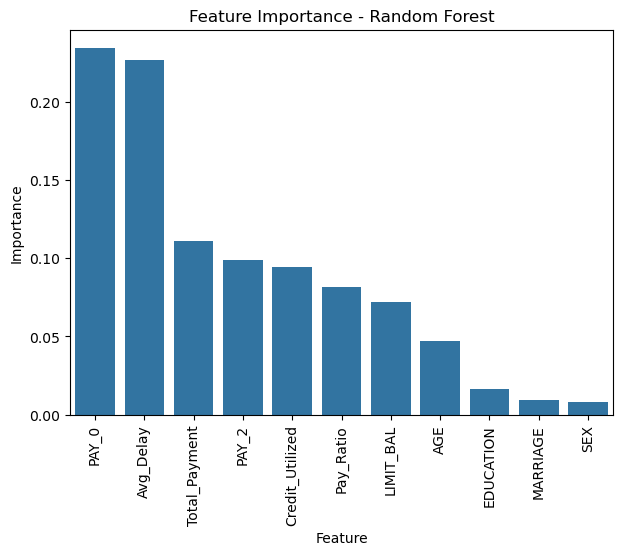

In [40]:
# FEATURE IMPORTANCE 
df_importance = pd.DataFrame({"Feature":X_train.columns, "Importance":best_rf.feature_importances_}) 
df_importance = df_importance.sort_values(by="Importance", ascending=False) 
print(df_importance) 

# plotting graph 
plt.figure(figsize=(7,5))
sns.barplot(data=df_importance, x="Feature", y="Importance")
plt.xticks(rotation=90)
plt.title("Feature Importance - Random Forest") 
plt.show()

<h2> XGBOOST IMPLEMENTATION </h2>

In [46]:
from xgboost import XGBClassifier 
xgb = XGBClassifier(n_estimators=200,max_depth=5,learning_rate=0.05,scale_pos_weight=3.5,random_state=42,eval_metric="logloss")

xgb.fit(X_train,y_train) 

y_pred_xgb=xgb.predict(X_test)
y_probability_xgb=xgb.predict_proba(X_test)[:,1]

# evaluate model 
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision :", precision_score(y_test, y_pred_xgb)) 
print("Recall :", recall_score(y_test, y_pred_xgb))  
print("F-1 Score :", f1_score(y_test, y_pred_xgb))  
print("ROC - AUC score :", roc_auc_score(y_test,y_probability_xgb))

Accuracy : 0.7693333333333333
Precision : 0.4830860534124629
Recall : 0.613413715146948
F-1 Score : 0.5405046480743692
ROC - AUC score : 0.7773283034495171


            Feature  Importance
5             PAY_0    0.673994
7         Avg_Delay    0.084249
6             PAY_2    0.044401
8     Total_Payment    0.033802
4         LIMIT_BAL    0.033243
10  Credit_Utilized    0.027057
9         Pay_Ratio    0.024606
2               SEX    0.022503
1         EDUCATION    0.020419
3          MARRIAGE    0.018001
0               AGE    0.017724


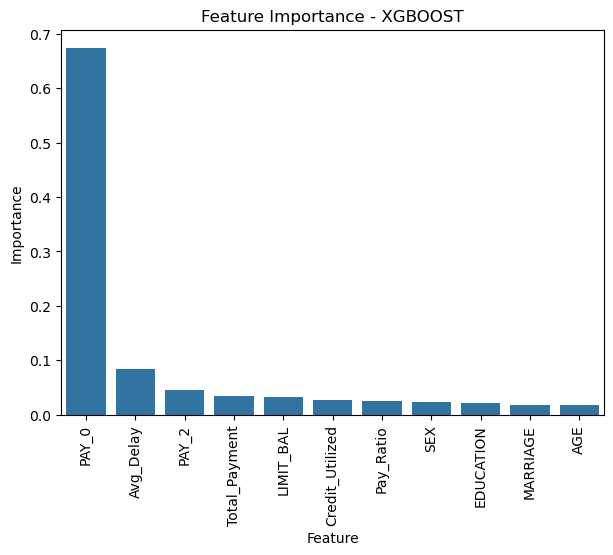

In [47]:
# FEATURE IMPORTANCE 
df_importance2 = pd.DataFrame({"Feature":X_train.columns, "Importance":xgb.feature_importances_}) 
df_importance2 = df_importance2.sort_values(by="Importance", ascending=False) 
print(df_importance2) 

# plotting graph 
plt.figure(figsize=(7,5))
sns.barplot(data=df_importance2, x="Feature", y="Importance")
plt.xticks(rotation=90)
plt.title("Feature Importance - XGBOOST") 
plt.show()

<h2>SHAP PLOTS

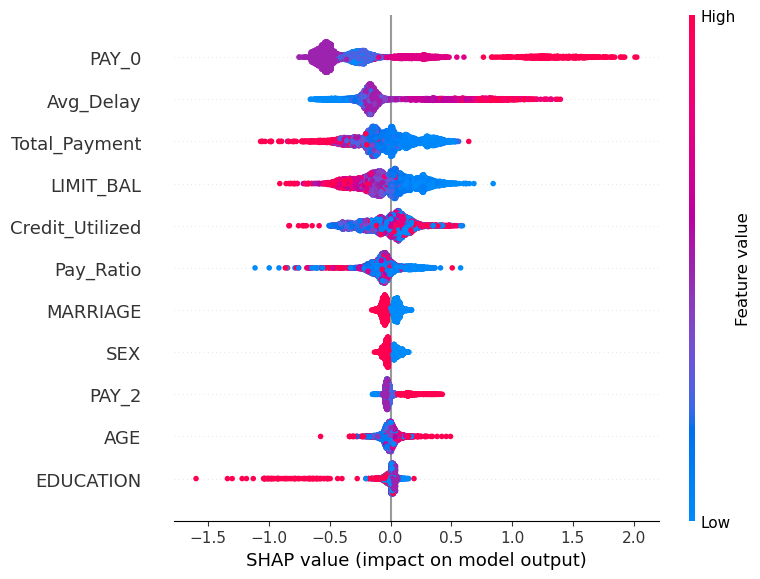

In [50]:
!pip install shap -q
import shap 

# create SHAP explainer for XGBOOST 
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test) 

# SHAP summary plot (Beeswarm) 
shap.summary_plot(shap_values,X_test,show=True) 


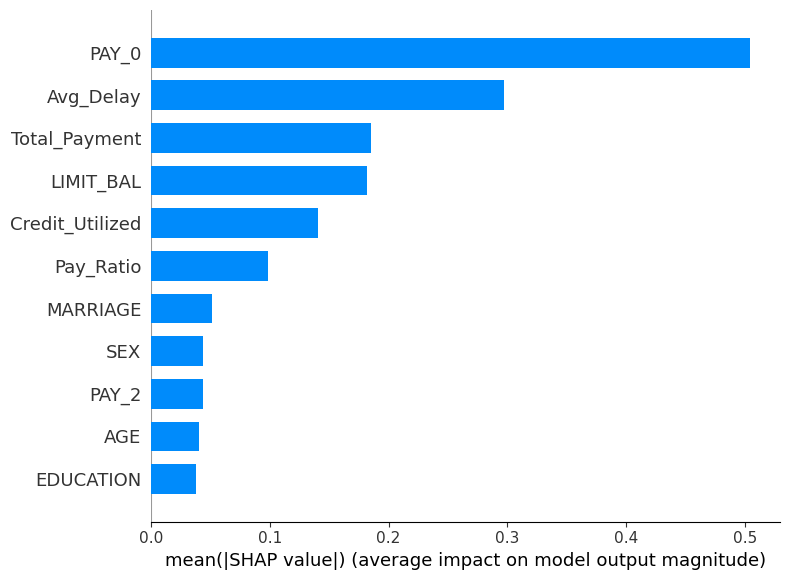

In [51]:
# SHAP Barplot 
shap.summary_plot(shap_values, X_test, plot_type = "bar", show=True) 


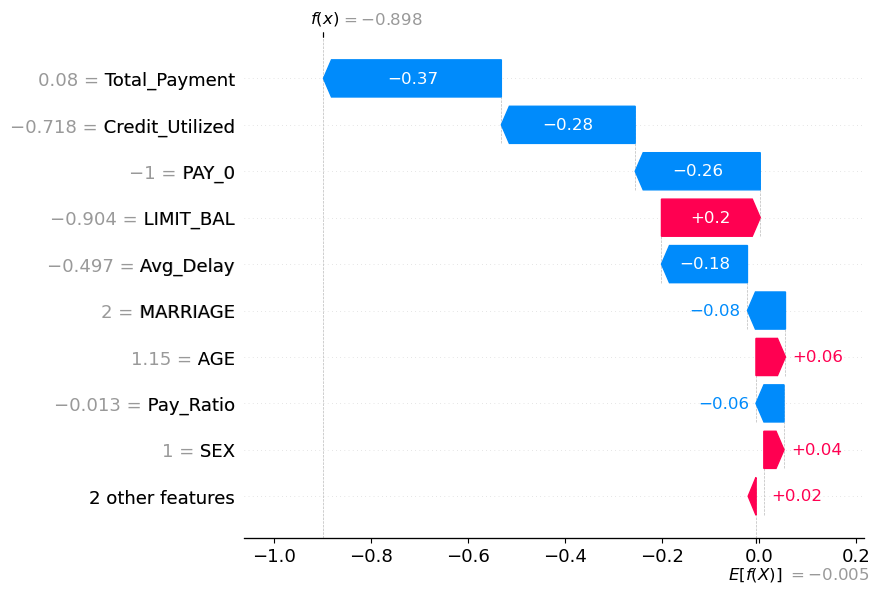

In [53]:
# SHAP Waterfall plot (for Single Customer) 
idx = 0 
shap.plots.waterfall(shap.Explanation(values=shap_values[idx], 
                                       base_values=explainer.expected_value, 
                                       data=X_test.iloc[idx], 
                                       feature_names = X_test.columns))

<h3>SAVING XGBOOST MODEL</h3>

In [56]:
import joblib
joblib.dump(xgb,"credit_default_model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']